### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
# Import Tensorflow, Keras, Numpy and Matplotlib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras

#### Collect Fashion mnist data from tf.keras.datasets 

In [0]:
#Download Fashion MNIST data from Keras in built dataset.
#Note : In Built dataset has train & test data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [39]:
#Get Train Y label unique value
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [40]:
#Get Test Y label unique value
np.unique(y_test)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [41]:
print("Train Data Shape : {0} ".format(x_train.shape))

Train Data Shape : (60000, 28, 28) 


In [42]:
print("Test Data Shape : {0} ".format(x_test.shape))

Test Data Shape : (10000, 28, 28) 


#### Change train and test labels into one-hot vectors

In [0]:
num_classes = 10 # No. of unique fashion product
# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [44]:
print(y_train.shape)
print('First 5 examples now are: ', y_train[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [45]:
print(y_test.shape)

(10000, 10)


#### Build the Graph

#### Initialize model, reshape & normalize data

In [0]:
#Initialize Sequential model
model = tf.keras.models.Sequential()
#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))
#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())



#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [0]:
#Add Dense Layer to create a hidden layer of 200 neurons with Relu activation
model.add(tf.keras.layers.Dense(200, activation='relu'))
#Add Dense Layer to create a hidden layer of 200 neurons with Relu activation
model.add(tf.keras.layers.Dense(100, activation='relu'))
#Add 25% Dropout layer 
model.add(tf.keras.layers.Dropout(0.25))

### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))
#Comile the model with categorical_crossentropy loss and adam optimizer
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [59]:
# Fit the model with 30 epochs and batch size 32
history =model.fit(x_train, y_train, 
          validation_data=(x_test, y_test), 
          epochs=30,
         batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/30
60000/60000 [==============================] - 13s 217us/sample - loss: 0.5134 - acc: 0.8155 - val_loss: 0.4153 - val_acc: 0.8480
Epoch 2/30
60000/60000 [==============================] - 9s 158us/sample - loss: 0.3944 - acc: 0.8537 - val_loss: 0.3983 - val_acc: 0.8541
Epoch 3/30
60000/60000 [==============================] - 10s 166us/sample - loss: 0.3598 - acc: 0.8661 - val_loss: 0.3732 - val_acc: 0.8668
Epoch 4/30
60000/60000 [==============================] - 10s 164us/sample - loss: 0.3382 - acc: 0.8752 - val_loss: 0.3761 - val_acc: 0.8689
Epoch 5/30
60000/60000 [==============================] - 11s 184us/sample - loss: 0.3161 - acc: 0.8829 - val_loss: 0.3365 - val_acc: 0.8811
Epoch 6/30
60000/60000 [==============================] - 12s 193us/sample - loss: 0.3014 - acc: 0.8861 - val_loss: 0.3582 - val_acc: 0.8776
Epoch 7/30
60000/60000 [==============================] - 10s 164us/sample - loss: 0.2872 - acc: 0.8937 -

### Plot Model Fit output for Train & Test Data

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])


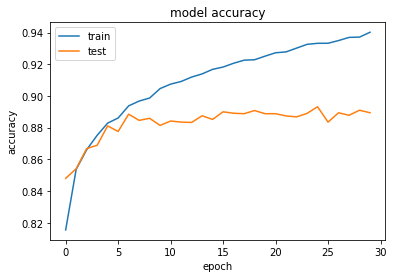

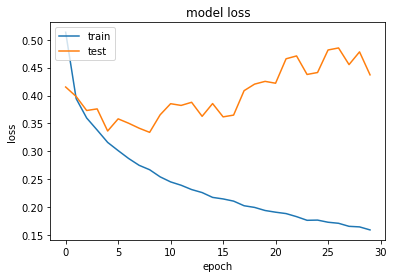

In [60]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Review Model

In [61]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_7 (Reshape)          (None, 784)               0         
_________________________________________________________________
batch_normalization_6 (Batch (None, 784)               3136      
_________________________________________________________________
dense_20 (Dense)             (None, 200)               157000    
_________________________________________________________________
dense_21 (Dense)             (None, 100)               20100     
_________________________________________________________________
dropout_5 (Dropout)          (None, 100)               0         
_________________________________________________________________
dense_22 (Dense)             (None, 10)                1010      
Total params: 181,246
Trainable params: 179,678
Non-trainable params: 1,568
____________________________________________

### Final Summary:



*   In Fashon MNIST dataset we have 60000 train data and 10000 test data.
*   We have initilize the keras based TF model with Reshape and batch normalize.
*   And then we have added two fully connected layers with 200 and 100 neurons       respectively with relu activation and added a dropout layer with p=0.25 as       requested.
*   And added the output layer with a fully connected layer with 10 neurons with     softmax activation. Use categorical_crossentropy loss and adam optimizer and     finally fit the model with train data.
*   We ran the model with 30 epochs and 32 batch size in this **we have around 94% 
    accuracy in Train data and 88% accuracy in Test Data**



